## Imports

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report

---
## Task 1: Data Understanding and Visualization

### 1.1 Load and Visualize Images from the Dataset

In [ ]:
train_dir = "/content/drive/MyDrive/FruitinAmazon/FruitinAmazon/train"
test_dir  = "/content/drive/MyDrive/FruitinAmazon/FruitinAmazon/test"

class_names = sorted(os.listdir(train_dir))
print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


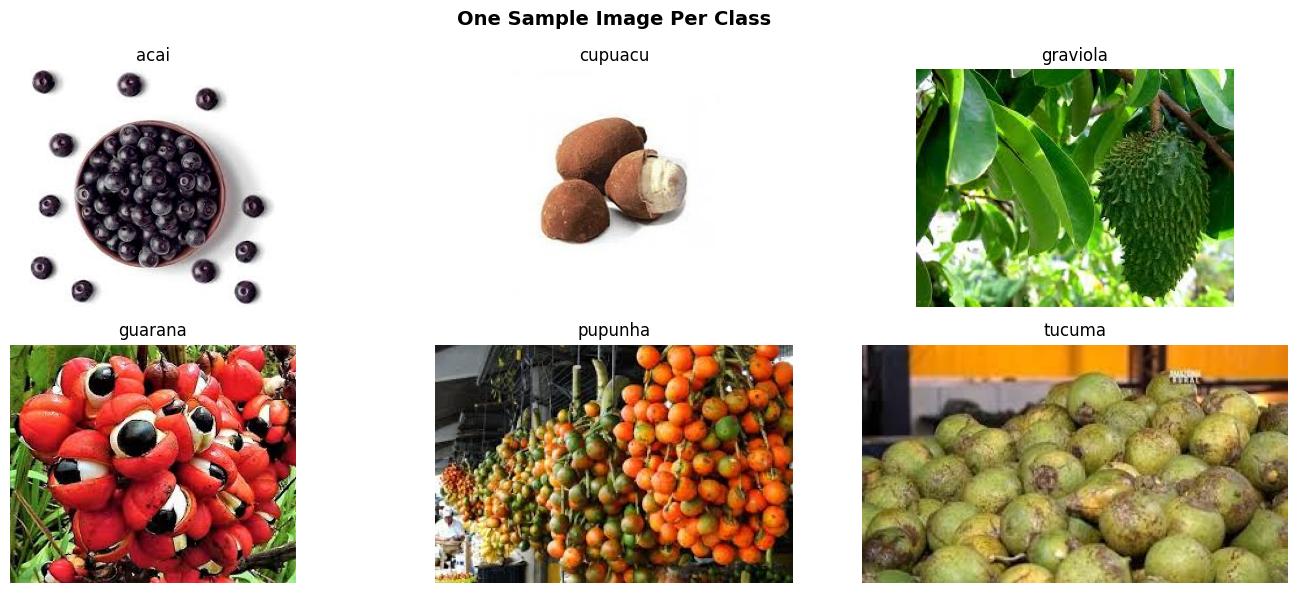

In [ ]:
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i], fontsize=12)
        ax.axis("off")
    else:
        ax.axis("off")

plt.suptitle("One Sample Image Per Class", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:**  
The dataset contains 6 classes of Amazon fruits: **pupunha, guarana, graviola, tucuma, acai, and cupuacu**. Each class has visually distinct images with different colors, textures, and shapes. The images vary in size and background, which will challenge the model to learn robust features.

### 1.2 Check for Corrupted Images

In [ ]:
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, SyntaxError):
                corrupted_images.append(img_path)
                os.remove(img_path)
                print(f"Removed corrupted image: {img_path}")

if not corrupted_images:
    print("No corrupted images found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted_images)}")

No corrupted images found.


---
## Task 2: Loading and Preprocessing Image Data in Keras

In [ ]:
img_height     = 128
img_width      = 128
batch_size     = 16
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1.0 / 255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

print("Training and Validation datasets loaded successfully.")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Training and Validation datasets loaded successfully.


---
## Task 3: Implement the CNN Model

Architecture as specified in the worksheet:
- Conv(32, 3x3, same) → ReLU → MaxPool(2x2)
- Conv(32, 3x3, same) → ReLU → MaxPool(2x2)
- Flatten → Dense(128) → Dense(64) → Dense(num_classes)

In [ ]:
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")

model = keras.Sequential([

    layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                  input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Number of classes: 6


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

---
## Task 4: Compile and Train the Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled.")

Model compiled.


In [ ]:

checkpoint_cb = ModelCheckpoint(
    'best_model_ws5.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop_cb = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Train
history = model.fit(
    train_ds,
    epochs=250,
    batch_size=16,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.2045 - loss: 2.6216
Epoch 1: val_accuracy improved from None to 0.83333, saving model to best_model_ws5.h5



Epoch 1: finished saving model to best_model_ws5.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 585ms/step - accuracy: 0.1944 - loss: 2.7118 - val_accuracy: 0.8333 - val_loss: 1.2208
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.0927 - loss: 1.8256
Epoch 2: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 333ms/step - accuracy: 0.1250 - loss: 1.8030 - val_accuracy: 0.4444 - val_loss: 1.6604
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.2948 - loss: 1.7509
Epoch 3: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 559ms/step - accuracy: 0.3333 - loss: 1.7254 - val_accuracy: 0.1111 - val_loss: 1.6870
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 0.2497 - loss: 1.6506
Epoch 4: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 722ms/step - accuracy: 0.2222 - loss: 1.6336 - val_accuracy: 0.1667 - val_loss: 1.5761
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 650ms/step - accuracy: 0.3809 - loss: 1


Epoch 7: finished saving model to best_model_ws5.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 880ms/step - accuracy: 0.8056 - loss: 0.6290 - val_accuracy: 0.9444 - val_loss: 0.5010
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 750ms/step - accuracy: 0.8781 - loss: 0.3546
Epoch 8: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 836ms/step - accuracy: 0.9167 - loss: 0.3411 - val_accuracy: 0.6667 - val_loss: 0.8397
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 648ms/step - accuracy: 1.0000 - loss: 0.1344
Epoch 9: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 820ms/step - accuracy: 1.0000 - loss: 0.1399 - val_accuracy: 0.8889 - val_loss: 0.5771
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 538ms/step - accuracy: 1.0000 - loss: 0.0489
Epoch 10: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 635ms/step - accuracy: 1.0000 - loss: 0.0477 - val_accuracy: 0.8889 - val_loss: 0.4651
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 883ms/step - accuracy: 0.9899 - loss

### Training & Validation Curves

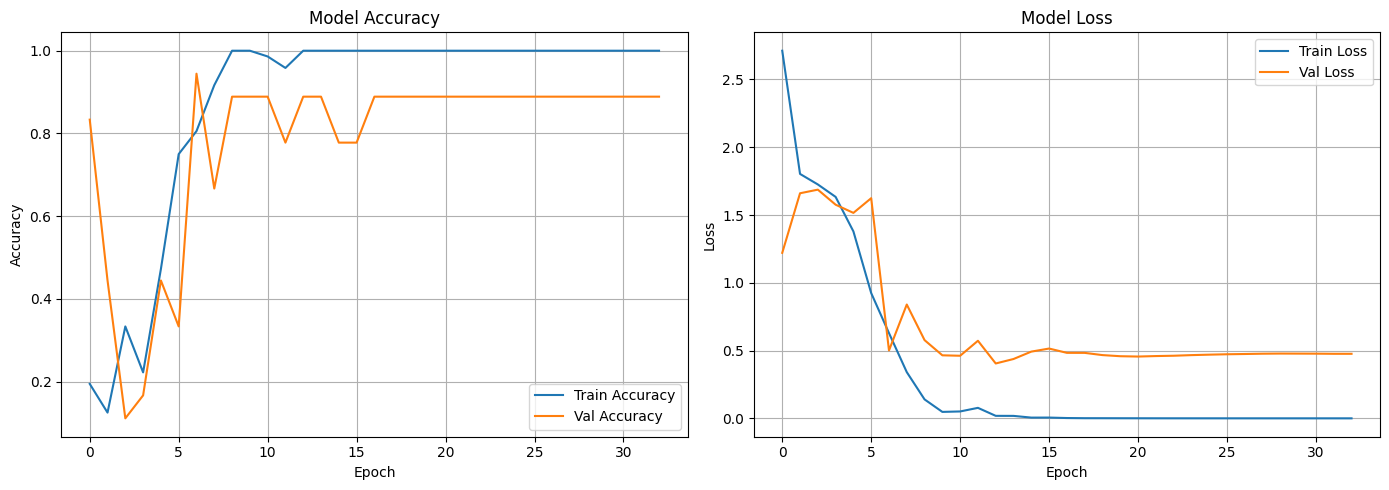

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_curves_ws5.png', dpi=150)
plt.show()

---
## Task 5: Evaluate the Model

In [ ]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Found 30 files belonging to 6 classes.
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.6667 - loss: 0.9639

Test Loss    : 0.9639
Test Accuracy: 0.6667


---
## Task 6: Save and Load the Model

In [ ]:
model.save('cnn_fruits_ws5.h5')
print("Model saved to cnn_fruits_ws5.h5")

loaded_model = keras.models.load_model('cnn_fruits_ws5.h5')
print("Model loaded successfully.")

loaded_loss, loaded_acc = loaded_model.evaluate(test_ds)
print(f"\nLoaded Model Test Loss    : {loaded_loss:.4f}")
print(f"Loaded Model Test Accuracy: {loaded_acc:.4f}")

Model saved to cnn_fruits_ws5.h5
Model loaded successfully.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.6667 - loss: 0.9639

Loaded Model Test Loss    : 0.9639
Loaded Model Test Accuracy: 0.6667


---
## Task 7: Predictions and Classification Report

In [ ]:

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print("\nClassification Report")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report
              precision    recall  f1-score   support

        acai       0.67      0.80      0.73         5
     cupuacu       0.60      0.60      0.60         5
    graviola       0.62      1.00      0.77         5
     guarana       1.00      0.80      0.89         5
     pupunha       1.00      0.40      0.57         5
      tucuma       0.40      0.40      0.40         5

    accuracy                           0.67        30
   macro avg       0.72      0.67      0.66        30
weighted avg       0.72      0.67      0.66        30

